In [1]:
import gc
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForQuestionAnswering,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    pipeline,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.style.use('seaborn-v0_8')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
hf_device = 0 if torch.cuda.is_available() else -1
print('device:', device)

PROJECT_DIR = Path('.') if Path('datasets').exists() else Path('Текущий контроль 15-16')
DATA_DIR = PROJECT_DIR / 'datasets' / 'polarity'
POS_PATH = DATA_DIR / 'positive_reviews.txt'
NEG_PATH = DATA_DIR / 'negative_reviews.txt'
MODELS_DIR = PROJECT_DIR / 'saved_models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRANSLATION_MODEL = 'Helsinki-NLP/opus-mt-ru-en'
QA_MODEL = 'distilbert-base-cased-distilled-squad'
SENTIMENT_MODEL = 'cointegrated/rubert-tiny-sentiment-balanced'
FINETUNE_MODEL = 'distilbert-base-uncased'


def clear_memory(*objects):
    for obj in objects:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def read_reviews(path):
    return [line.strip() for line in path.read_text(encoding='utf-8', errors='ignore').splitlines() if line.strip()]


def load_polarity_dataset():
    positive = read_reviews(POS_PATH)
    negative = read_reviews(NEG_PATH)
    texts = positive + negative
    labels = [1] * len(positive) + [0] * len(negative)
    return texts, labels


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train_loss')
    axes[0].plot(history['test_loss'], label='test_loss')
    axes[0].set_title(title + ' loss')
    axes[0].legend()
    axes[1].plot(history['test_acc'], label='test_acc', color='green')
    axes[1].set_title(title + ' accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx].clone().detach() for key, value in self.encodings.items()}
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        item['label'] = label
        item['labels'] = label
        return item


def move_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


@torch.no_grad()
def evaluate_transformer_classifier(model, data_loader, device):
    model.eval()
    losses = []
    preds = []
    targets = []
    for batch in data_loader:
        labels = batch['labels']
        targets.extend(labels.tolist())
        model_batch = {k: v for k, v in batch.items() if k != 'label'}
        model_batch = move_batch_to_device(model_batch, device)
        outputs = model(**model_batch)
        losses.append(outputs.loss.item() * labels.size(0))
        preds.extend(outputs.logits.argmax(dim=1).cpu().tolist())
    mean_loss = sum(losses) / max(len(targets), 1)
    acc = accuracy_score(targets, preds) if targets else 0.0
    return mean_loss, acc, preds, targets


def train_transformer_classifier(model, train_loader, test_loader, optimizer, epochs, device):
    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_samples = 0
        for batch in train_loader:
            labels = batch['labels']
            model_batch = {k: v for k, v in batch.items() if k != 'label'}
            model_batch = move_batch_to_device(model_batch, device)
            optimizer.zero_grad()
            outputs = model(**model_batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)
        train_loss = total_loss / max(total_samples, 1)
        test_loss, test_acc, _, _ = evaluate_transformer_classifier(model, test_loader, device)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        print(f'epoch {epoch}/{epochs}: train_loss={train_loss:.4f} test_loss={test_loss:.4f} test_acc={test_acc:.4f}')
    return history


def answer_question_manual(tokenizer, model, question, context):
    inputs = tokenizer(question, context, return_tensors='pt', truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    start_idx = int(outputs.start_logits.argmax())
    end_idx = int(outputs.end_logits.argmax())
    if end_idx < start_idx:
        end_idx = start_idx
    answer_tokens = inputs['input_ids'][0, start_idx:end_idx + 1]
    return tokenizer.decode(answer_tokens, skip_special_tokens=True).strip()


def predict_sentiment_manual(tokenizer, model, text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    pred_idx = int(outputs.logits.argmax(dim=1).item())
    return model.config.id2label[pred_idx]


/home/aleksey/Documents/mirea_lab/6 sem/algo-ml/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda:0


## 1. Pipelines


In [2]:
print('PROJECT_DIR =', PROJECT_DIR.resolve())
print('POS_PATH exists =', POS_PATH.exists(), POS_PATH)
print('NEG_PATH exists =', NEG_PATH.exists(), NEG_PATH)
texts, labels = load_polarity_dataset()
print('dataset size:', len(texts))
print('positive sample:', texts[0])
print('negative sample:', texts[-1])


PROJECT_DIR = /home/aleksey/Documents/mirea_lab/6 sem/algo-ml/Текущий контроль 15-16
POS_PATH exists = True datasets/polarity/positive_reviews.txt
NEG_PATH exists = True datasets/polarity/negative_reviews.txt
dataset size: 10662
positive sample: simplistic , silly and tedious .
negative sample: provides a porthole into that noble , trembling incoherence that defines us all .


[Документация по transformers.pipeline](https://huggingface.co/transformers/main_classes/pipelines.html)

[Model hub](https://huggingface.co/models)


1.1 Среди предобученных моделей найдите модель для перевода текста с русского языка на английский. Протестируйте данную модель на нескольких предложениях, используя `transformers.pipeline`. Выведите результаты работы в следующем виде:

```
sentence1_ru -> sentence1_en
sentence2_ru -> sentence2_en
```



In [3]:
translator = pipeline('translation_ru_to_en', model=TRANSLATION_MODEL, device=hf_device)
ru_sentences = [
    'Сегодня хорошая погода, и я иду в университет.',
    'Нейронные сети помогают решать сложные задачи обработки текста.',
    'Мне нужно перевести это предложение на английский язык.',
]
translations = translator(ru_sentences, max_length=128)
for sentence_ru, result in zip(ru_sentences, translations):
    print(f'{sentence_ru} -> {result["translation_text"]}')

if torch.cuda.is_available():
    translator.model.cpu()
clear_memory(translator)


/home/aleksey/Documents/mirea_lab/6 sem/algo-ml/.venv311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/aleksey/Documents/mirea_lab/6 sem/algo-ml/.venv311/lib/python3.11/site-packages/transformers/models/marian/tokenization_marian.py:194: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Сегодня хорошая погода, и я иду в университет. -> It's nice weather today, and I'm going to university.
Нейронные сети помогают решать сложные задачи обработки текста. -> Neuronets help solve complex text-processing problems.
Мне нужно перевести это предложение на английский язык. -> I need to translate this sentence into English.


1.2 Среди предобученных моделей найдите модель для поиска ответа в тексте. Протестируйте данную модель на нескольких предложениях, используя `transformers.pipeline`. Выведите на экран результаты в следующем виде:

```
Q: ...
A: ...
Q: ...
A: ...
```


In [4]:
qa_pipe = pipeline('question-answering', model=QA_MODEL, tokenizer=QA_MODEL, device=hf_device)
context = (
    'Alan Turing was a British mathematician and computer scientist. '
    'He played a major role in cracking the Enigma code during World War II. '
    'Turing is widely considered one of the fathers of modern computer science.'
)
questions = [
    'Who was Alan Turing?',
    'What code did Turing help crack?',
    'How is Turing regarded in computer science?',
]
for question in questions:
    answer = qa_pipe(question=question, context=context)
    print(f'Q: {question}')
    print(f'A: {answer["answer"]}')

if torch.cuda.is_available():
    qa_pipe.model.cpu()
clear_memory(qa_pipe)


Q: Who was Alan Turing?
A: British mathematician and computer scientist
Q: What code did Turing help crack?
A: Enigma code
Q: How is Turing regarded in computer science?
A: one of the fathers


1.3 Среди предобученных моделей найдите модель для классификации тональности русскоязычного текста (позитивный/негативный или позитивный/негативный/нейтральный). Протестируйте данную модель на нескольких предложениях, используя `transformers.pipeline`. Выведите результаты работы в следующем виде:

```
sentence1 -> class1
sentence2 -> class2
...
```


In [5]:
sentiment_pipe = pipeline('text-classification', model=SENTIMENT_MODEL, tokenizer=SENTIMENT_MODEL, device=hf_device)
ru_texts = [
    'Фильм получился очень сильным и трогательным.',
    'Это было ужасно скучно и затянуто.',
    'Нормальная работа, без особых впечатлений.',
]
results = sentiment_pipe(ru_texts)
for text, result in zip(ru_texts, results):
    print(f'{text} -> {result["label"]}')

if torch.cuda.is_available():
    sentiment_pipe.model.cpu()
clear_memory(sentiment_pipe)


Xformers is not installed correctly. If you want to use memory_efficient_attention to accelerate training use the following command to install Xformers
pip install xformers.


Фильм получился очень сильным и трогательным. -> neutral
Это было ужасно скучно и затянуто. -> negative
Нормальная работа, без особых впечатлений. -> positive


## 2. Токенизаторы и модели


[Auto Classes](https://huggingface.co/transformers/model_doc/auto.html)

[Tokenizer](https://transformers.main_classes/tokenizer.html?highlight=tokenizer#transformers.PreTrainedTokenizer.__call__)


2.1 Решите задачу 1.2, создав объект токенизатора (`transformers.AutoTokenizer`) и модель (`transformers.AutoModelForQuestionAnswering`).


In [6]:
qa_tokenizer = AutoTokenizer.from_pretrained(QA_MODEL)
qa_model = AutoModelForQuestionAnswering.from_pretrained(QA_MODEL).to(device)
context = (
    'Alan Turing was a British mathematician and computer scientist. '
    'He played a major role in cracking the Enigma code during World War II. '
    'Turing is widely considered one of the fathers of modern computer science.'
)
questions = [
    'Who was Alan Turing?',
    'What code did Turing help crack?',
    'How is Turing regarded in computer science?',
]
for question in questions:
    answer = answer_question_manual(qa_tokenizer, qa_model, question, context)
    print(f'Q: {question}')
    print(f'A: {answer}')

qa_model.cpu()
clear_memory(qa_model)


Q: Who was Alan Turing?
A: British mathematician and computer scientist
Q: What code did Turing help crack?
A: Enigma code
Q: How is Turing regarded in computer science?
A: one of the fathers


2.2 Решите задачу 1.3, создав объект токенизатора (`transformers.AutoTokenizer`) и модель (`transformers.AutoModelForSequenceClassification`).


In [7]:
sent_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
sent_model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL).to(device)
ru_texts = [
    'Фильм получился очень сильным и трогательным.',
    'Это было ужасно скучно и затянуто.',
    'Нормальная работа, без особых впечатлений.',
]
for text in ru_texts:
    label = predict_sentiment_manual(sent_tokenizer, sent_model, text)
    print(f'{text} -> {label}')

sent_model.cpu()
clear_memory(sent_model)


Фильм получился очень сильным и трогательным. -> neutral
Это было ужасно скучно и затянуто. -> negative
Нормальная работа, без особых впечатлений. -> positive


# 3. Fine tuning


3.1 Дообучите классификатор отзывов на основе модели `distilbert-base-uncased`.

Датасет: https://yadi.sk/d/mRXgc2aJSCncdw

* считайте данные, разбейте на обучающее и тестовое множество;
* создайте токенизатор `AutoTokenizer` для модели `distilbert-base-uncased` и преобразуйте с его помощью текстовые данные. Не забудьте выровнять длину всех последовательностей при помощи параметра `padding`;
* опишите класс `ReviewDataset`:
  * в данном случае удобнее, чтобы метод `__getitem__` возвращал словарь, а не кортеж (см. класс `MyDataset` ниже). Этот словарь должен содержать все данные, полученные после работы токенизатора плюс по ключу `label` должен находиться правильный ответ;
* создайте модель `AutoModelForSequenceClassification` с предобученными весами на основе `distilbert-base-uncased`;
  * при создании модели укажите параметр `num_labels=2`
* дообучите модель:
  * удобная особенность моделей из `transformers`: в метод `__call__` модели можно передать параметр `labels`, содержащий правильные ответы для обучения; тогда в словаре, который вернет метод `__call__` будет ключ `loss`, содержащий тензор со значением функции потерь, у которого можно вызвать метод `backward` и т.д. Таким образом, в данном случае функцию потерь объявлять не нужно;
  * для обучения используйте оптимизатор `torch.optim.AdamW`;
* измерьте значение accuracy на тестовом множестве.


train size: 8529
test size: 2133


/home/aleksey/Documents/mirea_lab/6 sem/algo-ml/.venv311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (in

epoch 1/2: train_loss=0.4126 test_loss=0.3532 test_acc=0.8406
epoch 2/2: train_loss=0.2353 test_loss=0.4012 test_acc=0.8354


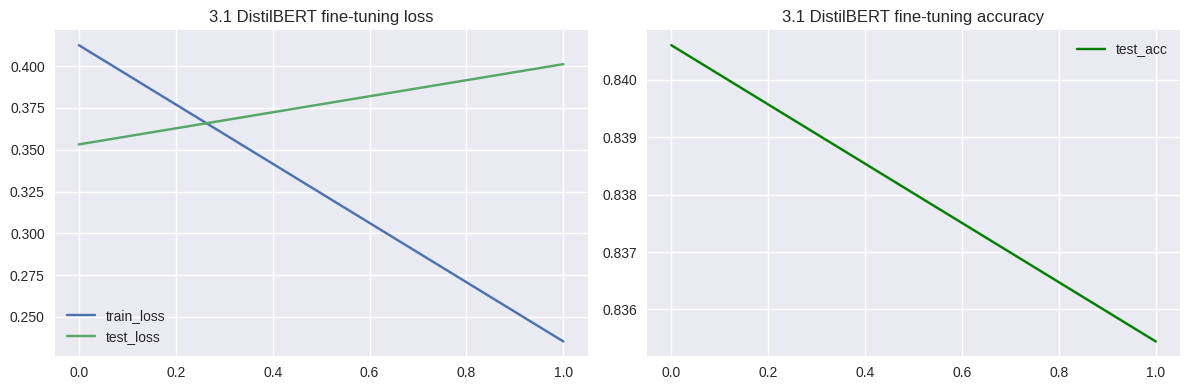

3.1 test accuracy: 0.8354430379746836
true=negative pred=positive text="its maker , steven spielberg , hasn't had so much fun in two decades , since he was schlepping indiana jones around the globe in search of a giant misplaced ashtray ."
true=negative pred=negative text="it's not a classic spy-action or buddy movie , but it's entertaining enough and worth a look ."
true=positive pred=positive text="hope keeps arising that the movie will live up to the apparent skills of its makers and the talents of its actors , but it doesn't ."
true=negative pred=negative text="rich in shadowy metaphor and as sharp as a samurai sword , jiang wen's devils on the doorstep is a wartime farce in the alternately comic and gut-wrenching style of joseph heller o"
true=positive pred=positive text='shrewd but pointless .'


In [8]:
texts, labels = load_polarity_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)
print('train size:', len(X_train))
print('test size:', len(X_test))

finetune_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL)
train_encodings = finetune_tokenizer(X_train, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
test_encodings = finetune_tokenizer(X_test, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
train_dataset = ReviewDataset(train_encodings, y_train)
test_dataset = ReviewDataset(test_encodings, y_test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

finetune_model = AutoModelForSequenceClassification.from_pretrained(FINETUNE_MODEL, num_labels=2).to(device)
optimizer = optim.AdamW(finetune_model.parameters(), lr=2e-5)
history = train_transformer_classifier(finetune_model, train_loader, test_loader, optimizer, epochs=2, device=device)
plot_history(history, '3.1 DistilBERT fine-tuning')

test_loss, test_acc, preds, targets = evaluate_transformer_classifier(finetune_model, test_loader, device)
print('3.1 test accuracy:', test_acc)

id2label = {0: 'negative', 1: 'positive'}
for text, pred, true_label in zip(X_test[:5], preds[:5], y_test[:5]):
    preview = text.replace('\n', ' ')[:180]
    print(f'true={id2label[true_label]} pred={id2label[pred]} text={preview!r}')

torch.save({
    'model_state': finetune_model.state_dict(),
    'tokenizer_name': FINETUNE_MODEL,
}, MODELS_DIR / 'distilbert_review_classifier.pth')

finetune_model.cpu()
clear_memory(finetune_model, optimizer, history, train_encodings, test_encodings)
